In [9]:
import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import butter, filtfilt
from concurrent.futures import ProcessPoolExecutor

SAMPLING_RATE = 360
WINDOW_BEFORE = 90
WINDOW_AFTER = 100

AAMI_MAPPING = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'f': 4, 'Q': 4
}

DS1_TRAIN_IDS = [
    '101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122',
    '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230'
]

DS2_TEST_IDS = [
    '100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210',
    '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234'
]

RECORD_IDS = DS1_TRAIN_IDS + DS2_TEST_IDS

def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=SAMPLING_RATE, order=2):
    nyquist = 0.5 * fs
    b, a = butter(order, [lowcut / nyquist, highcut / nyquist], btype='band')
    return filtfilt(b, a, data)

def normalize_signal(data):
    std = np.std(data)
    if std == 0:
        return data - np.mean(data)
    return (data - np.mean(data)) / std

def process_single_record(record_id, data_dir='./mitdb'):
    path = os.path.join(data_dir, record_id)
    if not os.path.exists(f"{path}.dat"):
        return [], [], []

    record = wfdb.rdrecord(path)
    annotation = wfdb.rdann(path, 'atr')
    
    signal = record.p_signal[:, 0]
    filtered_signal = bandpass_filter(signal)
    
    X_rec, y_rec, record_ids = [], [], []
    
    for peak, symbol in zip(annotation.sample, annotation.symbol):
        if symbol in AAMI_MAPPING:
            label = AAMI_MAPPING[symbol]
            if peak - WINDOW_BEFORE >= 0 and peak + WINDOW_AFTER < len(filtered_signal):
                segment = filtered_signal[peak - WINDOW_BEFORE : peak + WINDOW_AFTER]
                X_rec.append(normalize_signal(segment))
                y_rec.append(label)
                record_ids.append(record_id)
                
    return X_rec, y_rec, record_ids

if __name__ == "__main__":
    data_dir = './mitdb'
    if not os.path.exists(data_dir):
        wfdb.dl_database('mitdb', dl_dir=data_dir)

    print("Extracting beats with Patient Record IDs...")
    X, y, records = [], [], []
    
    with ProcessPoolExecutor() as executor:
        futures = [executor.submit(process_single_record, rid, data_dir) for rid in RECORD_IDS]
        for future in futures:
            X_rec, y_rec, r_ids = future.result()
            X.extend(X_rec)
            y.extend(y_rec)
            records.extend(r_ids)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    feature_cols = [f'sample_{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feature_cols)
    df['label'] = y
    df['record_id'] = records  # Track patient/record ID per beat

    df.to_csv('mitbih_interpatient_processed.csv', index=False)
    print("Saved to 'mitbih_interpatient_processed.csv' successfully!")

Extracting beats with Patient Record IDs...


Saved to 'mitbih_interpatient_processed.csv' successfully!


In [10]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('mitbih_interpatient_processed.csv')

# Define patient sets
DS1_TRAIN_IDS = [
    '101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122',
    '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230'
]

# 1. Filter Train and Test sets strictly by patient ID
train_df = df[df['record_id'].astype(str).isin(DS1_TRAIN_IDS)]
test_df  = df[~df['record_id'].astype(str).isin(DS1_TRAIN_IDS)]

# 2. Extract features and target labels
X_train_2d = train_df.drop(columns=['label', 'record_id']).values.astype(np.float32)
y_train    = train_df['label'].values.astype(np.int64)

X_test_2d  = test_df.drop(columns=['label', 'record_id']).values.astype(np.float32)
y_test     = test_df['label'].values.astype(np.int64)

# 3. Create Validation set from a subset of training patients (e.g., 4 patients from DS1)
val_patient_ids = ['118', '119', '208', '209']

val_mask   = train_df['record_id'].astype(str).isin(val_patient_ids)
X_val_2d   = X_train_2d[val_mask]
y_val      = y_train[val_mask]

X_train_2d = X_train_2d[~val_mask]
y_train    = y_train[~val_mask]

# 4. Reshape for 3D CNN / LSTM input
X_train_3d = np.expand_dims(X_train_2d, axis=-1)
X_val_3d   = np.expand_dims(X_val_2d, axis=-1)
X_test_3d  = np.expand_dims(X_test_2d, axis=-1)

print(f"Inter-Patient Split Verification:")
print(f" - Train Beats (DS1 Sub): {X_train_2d.shape}")
print(f" - Val Beats (DS1 Sub):   {X_val_2d.shape}")
print(f" - Test Beats (DS2 All):  {X_test_2d.shape}")

Inter-Patient Split Verification:
 - Train Beats (DS1 Sub): (40786, 190)
 - Val Beats (DS1 Sub):   (10222, 190)
 - Test Beats (DS2 All):  (49698, 190)


Loading dataset...

Dataset Split Summary:
 - Train Set:      40786 beats (18 Patients)
 - Validation Set: 10222 beats (4 Patients)
 - Test Set:       49698 beats (Unseen DS2 Patients)

Computed Class Weights (DL): {0: np.float64(0.21500263574064313), 1: np.float64(17.61814254859611), 2: np.float64(3.493447537473233), 3: np.float64(194.21904761904761), 4: np.float64(1359.5333333333333)}

TRAINING MODEL 1: XGBoost Classifier
Model saved to 'saved_models/ecg_xgboost.json'

XGBoost Best Iteration: 48
XGBoost Test Accuracy: 0.7261
                      precision    recall  f1-score   support

          N (Normal)       0.94      0.75      0.83     44246
S (Supraventricular)       0.03      0.11      0.04      1837
     V (Ventricular)       0.56      0.87      0.68      3220
          F (Fusion)       0.00      0.00      0.00       388
         Q (Unknown)       0.00      0.00      0.00         7

            accuracy                           0.73     49698
           macro avg       0.31

/home/kishore/Desktop/MajorProject/ecg_env/lib64/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


318/319 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4585 - loss: 1.6479
Epoch 1: val_loss improved from None to 1.48884, saving model to saved_models/ecg_1dcnn.keras

Epoch 1: finished saving model to saved_models/ecg_1dcnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.4585 - loss: 1.6513 - val_accuracy: 0.0806 - val_loss: 1.4888
Epoch 2/35
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4519 - loss: 1.2421
Epoch 2: val_loss improved from 1.48884 to 1.31244, saving model to saved_models/ecg_1dcnn.keras

Epoch 2: finished saving model to saved_models/ecg_1dcnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.4519 - loss: 1.2421 - val_accuracy: 0.4696 - val_loss: 1.3124
Epoch 3/35
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4684 - loss: 1.3370
Epoch 3: val_loss improved from 1.31244 to 1.06088, saving model to saved_models/ecg_1dcnn.keras

Epoch 3: finished saving model to saved_models/ecg_1dcnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 19s

/home/kishore/Desktop/MajorProject/ecg_env/lib64/python3.11/site-packages/keras/src/layers/rnn/bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.3949 - loss: 1.5617
Epoch 1: val_loss improved from None to 1.37917, saving model to saved_models/ecg_bilstm.keras

Epoch 1: finished saving model to saved_models/ecg_bilstm.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 153s 463ms/step - accuracy: 0.3949 - loss: 1.5617 - val_accuracy: 0.4040 - val_loss: 1.3792
Epoch 2/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.4332 - loss: 1.5026
Epoch 2: val_loss did not improve from 1.37917
319/319 ━━━━━━━━━━━━━━━━━━━━ 157s 493ms/step - accuracy: 0.4332 - loss: 1.5026 - val_accuracy: 0.1640 - val_loss: 2.0137
Epoch 3/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.4001 - loss: 1.3553
Epoch 3: val_loss improved from 1.37917 to 1.35360, saving model to saved_models/ecg_bilstm.keras

Epoch 3: finished saving model to saved_models/ecg_bilstm.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 143s 447ms/step - accuracy: 0.4001 - loss: 1.3553 - val_accuracy: 0.5361 - val_loss: 1.3536
Epoch 4/25
319

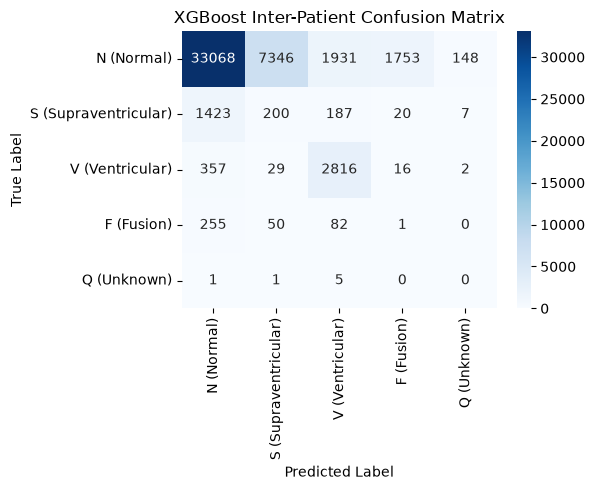

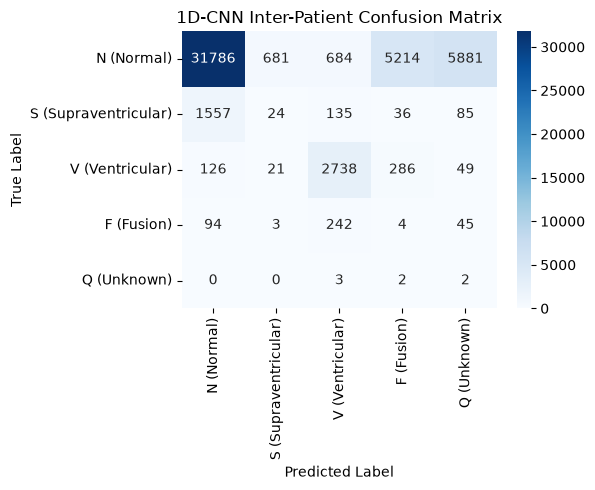

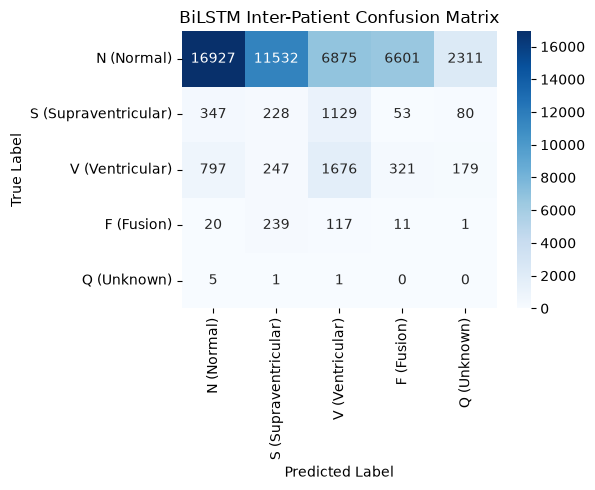


Pipeline finished! Trained models are available in 'saved_models/'.


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Ensure output directory exists for saving trained models
os.makedirs('saved_models', exist_ok=True)

# ---------------------------------------------------------------------------
# 1. Load Data & Perform Inter-Patient Split
# ---------------------------------------------------------------------------
print("Loading dataset...")
df = pd.read_csv('mitbih_interpatient_processed.csv')

# Standard De Chazal AAMI Patient Partition
DS1_TRAIN_PATIENTS = [
    '101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122',
    '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230'
]

# Set aside 4 DS1 patients strictly for Validation
VAL_PATIENTS = ['118', '119', '208', '209']
TRAIN_PATIENTS = [p for p in DS1_TRAIN_PATIENTS if p not in VAL_PATIENTS]

df['record_id'] = df['record_id'].astype(str)

# Filter dataframe into Train, Val, and Test sets by Patient ID
train_df = df[df['record_id'].isin(TRAIN_PATIENTS)]
val_df   = df[df['record_id'].isin(VAL_PATIENTS)]
test_df  = df[~df['record_id'].isin(DS1_TRAIN_PATIENTS)]  # All DS2 patients

# Extract 2D features and labels
X_train_2d = train_df.drop(columns=['label', 'record_id']).values.astype(np.float32)
y_train    = train_df['label'].values.astype(np.int64)

X_val_2d   = val_df.drop(columns=['label', 'record_id']).values.astype(np.float32)
y_val      = val_df['label'].values.astype(np.int64)

X_test_2d  = test_df.drop(columns=['label', 'record_id']).values.astype(np.float32)
y_test     = test_df['label'].values.astype(np.int64)

# Reshape X to 3D for Deep Learning models: (Batch, Timesteps, Channels)
X_train_3d = np.expand_dims(X_train_2d, axis=-1)
X_val_3d   = np.expand_dims(X_val_2d, axis=-1)
X_test_3d  = np.expand_dims(X_test_2d, axis=-1)

class_names = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusion)', 'Q (Unknown)']

print("\nDataset Split Summary:")
print(f" - Train Set:      {X_train_2d.shape[0]} beats ({len(TRAIN_PATIENTS)} Patients)")
print(f" - Validation Set: {X_val_2d.shape[0]} beats ({len(VAL_PATIENTS)} Patients)")
print(f" - Test Set:       {X_test_2d.shape[0]} beats (Unseen DS2 Patients)")

# ---------------------------------------------------------------------------
# 2. Compute Class & Sample Weights (Handling Class Imbalance)
# ---------------------------------------------------------------------------
# Keras Class Weights Dictionary
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
keras_class_weights = dict(enumerate(class_weights_arr))

# XGBoost Sample Weights Array
xgb_sample_weights = compute_sample_weight('balanced', y_train)

print("\nComputed Class Weights (DL):", keras_class_weights)

# ---------------------------------------------------------------------------
# 3. Setup Keras Callbacks (Early Stopping & Model Checkpointing)
# ---------------------------------------------------------------------------
def create_callbacks(model_name):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
    checkpoint = ModelCheckpoint(
        filepath=f'saved_models/{model_name}.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    return [early_stop, checkpoint]

# ---------------------------------------------------------------------------
# 4. Model 1: XGBoost Classifier
# ---------------------------------------------------------------------------
print("\n" + "="*50)
print("TRAINING MODEL 1: XGBoost Classifier")
print("="*50)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    objective='multi:softprob',
    num_class=5,
    tree_method='hist',
    early_stopping_rounds=10,
    random_state=42
)

# Fit XGBoost with sample weights for class imbalance
xgb_model.fit(
    X_train_2d, y_train,
    sample_weight=xgb_sample_weights,
    eval_set=[(X_val_2d, y_val)],
    verbose=False
)

# Save XGBoost Model
xgb_path = 'saved_models/ecg_xgboost.json'
xgb_model.save_model(xgb_path)
print(f"Model saved to '{xgb_path}'")

# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test_2d)
print(f"\nXGBoost Best Iteration: {xgb_model.best_iteration}")
print(f"XGBoost Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

# ---------------------------------------------------------------------------
# 5. Model 2: 1D Convolutional Neural Network (1D-CNN)
# ---------------------------------------------------------------------------
print("\n" + "="*50)
print("TRAINING MODEL 2: 1D-CNN (Keras/TensorFlow)")
print("="*50)

cnn_model = keras.Sequential([
    layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=(190, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    
    layers.Conv1D(64, kernel_size=5, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train 1D-CNN with class weights and callbacks
history_cnn = cnn_model.fit(
    X_train_3d, y_train,
    epochs=35,
    batch_size=128,
    validation_data=(X_val_3d, y_val),
    class_weight=keras_class_weights,
    callbacks=create_callbacks('ecg_1dcnn'),
    verbose=1
)

# Evaluate 1D-CNN
y_pred_cnn_probs = cnn_model.predict(X_test_3d)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

print(f"\n1D-CNN Test Accuracy: {accuracy_score(y_test, y_pred_cnn):.4f}")
print(classification_report(y_test, y_pred_cnn, target_names=class_names))

# ---------------------------------------------------------------------------
# 6. Model 3: Bidirectional LSTM (BiLSTM)
# ---------------------------------------------------------------------------
print("\n" + "="*50)
print("TRAINING MODEL 3: BiLSTM (Keras/TensorFlow)")
print("="*50)

bilstm_model = keras.Sequential([
    layers.Bidirectional(layers.LSTM(64, return_sequences=True), input_shape=(190, 1)),
    layers.Dropout(0.2),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(5, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train BiLSTM with class weights and callbacks
history_bilstm = bilstm_model.fit(
    X_train_3d, y_train,
    epochs=25,
    batch_size=128,
    validation_data=(X_val_3d, y_val),
    class_weight=keras_class_weights,
    callbacks=create_callbacks('ecg_bilstm'),
    verbose=1
)

# Evaluate BiLSTM
y_pred_bilstm_probs = bilstm_model.predict(X_test_3d)
y_pred_bilstm = np.argmax(y_pred_bilstm_probs, axis=1)

print(f"\nBiLSTM Test Accuracy: {accuracy_score(y_test, y_pred_bilstm):.4f}")
print(classification_report(y_test, y_pred_bilstm, target_names=class_names))

# ---------------------------------------------------------------------------
# 7. Confusion Matrix Visualization
# ---------------------------------------------------------------------------
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

plot_cm(y_test, y_pred_xgb, "XGBoost Inter-Patient Confusion Matrix")
plot_cm(y_test, y_pred_cnn, "1D-CNN Inter-Patient Confusion Matrix")
plot_cm(y_test, y_pred_bilstm, "BiLSTM Inter-Patient Confusion Matrix")

print("\nPipeline finished! Trained models are available in 'saved_models/'.")

In [13]:
y_train_pred = xgb_model.predict(X_train_2d)
y_val_pred = xgb_model.predict(X_val_2d)

print(f"Train Accuracy      : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy       : {accuracy_score(y_test, y_pred_xgb):.4f}")

Train Accuracy      : 0.9764
Validation Accuracy : 0.6992
Test Accuracy       : 0.7261
